In [2]:
import yfinance

stock_ticker = "AMD"
start_date = "2019-01-01"
end_date = "2024-01-01"

dataframe = yfinance.download(tickers = stock_ticker,
                 start = start_date,
                 end = end_date)

dataframe

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMD,AMD,AMD,AMD,AMD
Date,,,,,
2019-01-02,18.830000,19.000000,17.980000,18.010000,87148700
2019-01-03,17.049999,18.680000,16.940001,18.420000,117277600
2019-01-04,19.000000,19.070000,17.430000,17.549999,111878600
2019-01-07,20.570000,20.680000,19.000000,19.440001,107157000
2019-01-08,20.750000,21.200001,19.680000,21.190001,121271000
...,...,...,...,...,...
2023-12-22,139.600006,140.699997,138.309998,140.479996,35370400
2023-12-26,143.410004,143.850006,139.919998,140.070007,47157400


In [3]:
import numpy

Fell = 1
Rose = -1

dataframe["Price Rose/Fell"] = numpy.where(dataframe["Close"].shift(-1) > dataframe["Close"], Fell, Rose)

dataframe

Price,Close,High,Low,Open,Volume,Price Rose/Fell
Ticker,AMD,AMD,AMD,AMD,AMD,
Date,,,,,,
2019-01-02,18.830000,19.000000,17.980000,18.010000,87148700,-1
2019-01-03,17.049999,18.680000,16.940001,18.420000,117277600,1
2019-01-04,19.000000,19.070000,17.430000,17.549999,111878600,1
2019-01-07,20.570000,20.680000,19.000000,19.440001,107157000,1
2019-01-08,20.750000,21.200001,19.680000,21.190001,121271000,-1
...,...,...,...,...,...,...
2023-12-22,139.600006,140.699997,138.309998,140.479996,35370400,1
2023-12-26,143.410004,143.850006,139.919998,140.070007,47157400,1


In [12]:
X = dataframe.iloc[:, 0:4].values

X

array([[ 18.82999992,  19.        ,  17.97999954,  18.01000023],
       [ 17.04999924,  18.68000031,  16.94000053,  18.42000008],
       [ 19.        ,  19.06999969,  17.43000031,  17.54999924],
       ...,
       [146.07000732, 146.25      , 143.17999268, 144.72000122],
       [148.75999451, 150.41000366, 145.94999695, 146.80000305],
       [147.41000366, 151.05000305, 147.19999695, 149.5       ]])

In [13]:
x_before = dataframe.iloc[:, 0:4]

x_before

Price,Close,High,Low,Open
Ticker,AMD,AMD,AMD,AMD
Date,,,,
2019-01-02,18.830000,19.000000,17.980000,18.010000
2019-01-03,17.049999,18.680000,16.940001,18.420000
2019-01-04,19.000000,19.070000,17.430000,17.549999
2019-01-07,20.570000,20.680000,19.000000,19.440001
2019-01-08,20.750000,21.200001,19.680000,21.190001
...,...,...,...,...
2023-12-22,139.600006,140.699997,138.309998,140.479996
2023-12-26,143.410004,143.850006,139.919998,140.070007


In [14]:
y = dataframe.iloc[:, 5].values

y

array([-1,  1,  1, ...,  1, -1, -1])

In [15]:
from sklearn import preprocessing

X = preprocessing.StandardScaler().fit(X).transform(X.astype(float))

X

array([[-1.79765909, -1.80170361, -1.81331414, -1.82058191],
       [-1.85167836, -1.81121366, -1.84557184, -1.8081492 ],
       [-1.79249995, -1.79962329, -1.8303735 , -1.83453085],
       ...,
       [ 2.06380695,  1.98003241,  2.07002017,  2.02173517],
       [ 2.14544239,  2.10366334,  2.15593753,  2.08480853],
       [ 2.10447302,  2.12268345,  2.19470884,  2.16668245]])

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

X_train.shape

(1006, 4)

In [21]:
X_test.shape

(252, 4)

In [22]:
y_train.shape

(1006,)

In [23]:
y_test.shape

(252,)

In [24]:
from sklearn.neighbors import KNeighborsClassifier

k = 3

model = KNeighborsClassifier(n_neighbors = k)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

from sklearn import metrics

testing_accuracy = metrics.accuracy_score(y_test, prediction)

testing_accuracy

0.44841269841269843

In [25]:
training_accuracy = metrics.accuracy_score(y_train, model.predict(X_train))

training_accuracy

0.7335984095427436

In [26]:
model_10k = KNeighborsClassifier(n_neighbors = 10)

model_10k.fit(X_train, y_train)

prediction_10k = model_10k.predict(X_test)

testing_accuracy_10k = metrics.accuracy_score(y_test, prediction_10k)

testing_accuracy_10k

0.5

In [35]:
Max_k = 25
Min_k = 1
accuracy_scores = numpy.zeros((Max_k - 1))
standard_accuracies = numpy.zeros((Max_k - 1))
for k in range(Min_k, Max_k):
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    accuracy_scores[k - 1] = metrics.accuracy_score(y_test, prediction)
    standard_accuracies[k - 1] = numpy.std(prediction == y_test)/numpy.sqrt(prediction.shape[0])
print(accuracy_scores[k - 1])

0.47619047619047616


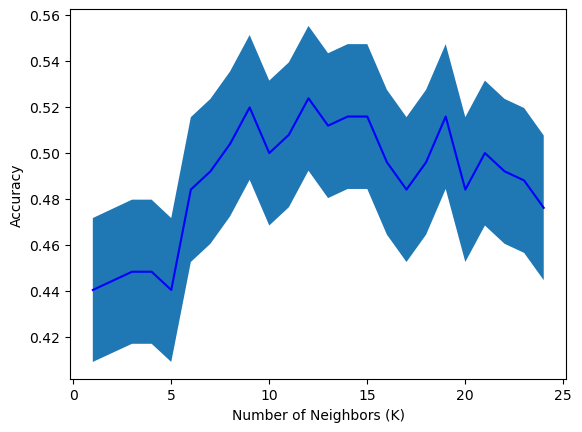

In [36]:
import matplotlib.pyplot as pyplot

pyplot.plot(range(Min_k, Max_k), accuracy_scores, 'blue')

pyplot.fill_between(range(Min_k, Max_k), accuracy_scores - 1 * standard_accuracies, accuracy_scores + 1 * standard_accuracies)

pyplot.xlabel('Number of Neighbors (K)')

pyplot.ylabel('Accuracy')

pyplot.show()

In [37]:
print("Highest Accuracy K: ", accuracy_scores.argmax() + 1) 

Highest Accuracy K:  12
